In [29]:

# https://raw.githubusercontent.com/blastchar/telco-customer-churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv

# Predict whether a customer will churn (leave the company) or not.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score, classification_report, roc_auc_score

In [2]:
# =====================================================
# 1. Load Dataset
# =====================================================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Shape: ", df.shape)
print(df.head())

Shape:  (7043, 21)
   customerID  gender  SeniorCitizen Partner  ...              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes  ...           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No  ...               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No  ...               Mailed check           53.85       108.15   Yes
3  7795-CFOCW    Male              0      No  ...  Bank transfer (automatic)           42.30      1840.75    No
4  9237-HQITU  Female              0      No  ...           Electronic check           70.70       151.65   Yes

[5 rows x 21 columns]


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df['Churn']

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [5]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [7]:
# =====================================================
# 2. Basic Cleaning
# =====================================================

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce" #If conversion fails, don't throw an error. Replace the value with NaN
)

df.dropna(inplace=True)

In [8]:
# =====================================================
# 3. Target Encoding
# =====================================================

df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [10]:
# =====================================================
# 4. Features and Target
# =====================================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [12]:
# =====================================================
# 5. Numerical & Categorical Columns
# =====================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features: ")
print(numerical_features)

print("\nCategorical Features: ")
print(categorical_features)


Numerical Features: 
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features: 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
# =====================================================
# 6. Preprocessing
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [15]:
preprocessing

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [18]:
# =====================================================
# 7. Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [19]:
# =====================================================
# 8. Baseline Pipeline
# =====================================================

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=5000))  # At most 5000 optimization steps
    ]
)

baseline_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
# =====================================================
# 9. Predictions
# =====================================================

y_pred = baseline_pipeline.predict(X_test)

y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

In [21]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [22]:
y_prob

array([0.01751303, 0.59192131, 0.00482103, ..., 0.13098875, 0.02525535,
       0.00444712], shape=(1407,))

In [23]:
# =====================================================
# 10. Accuracy
# =====================================================

baseline_accuracy = accuracy_score(
    y_test, y_pred
)

print("\nBaseline Accuracy: ")
print(round(baseline_accuracy, 4))


Baseline Accuracy: 
0.8038


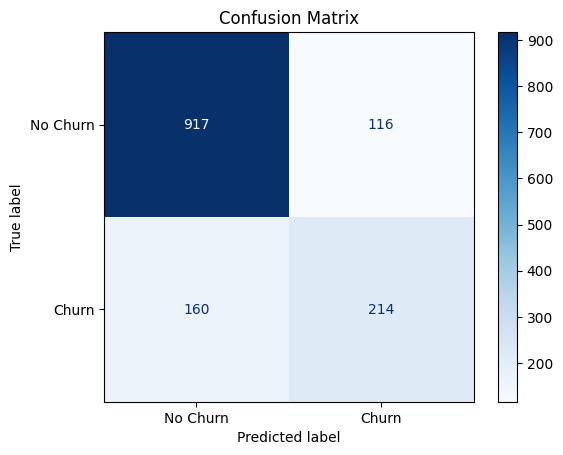

In [24]:
# =====================================================
# 11. Confusion Matrix
# =====================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [26]:
# =====================================================
# 12. Classification Report
# =====================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test, y_pred
    )
)


Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



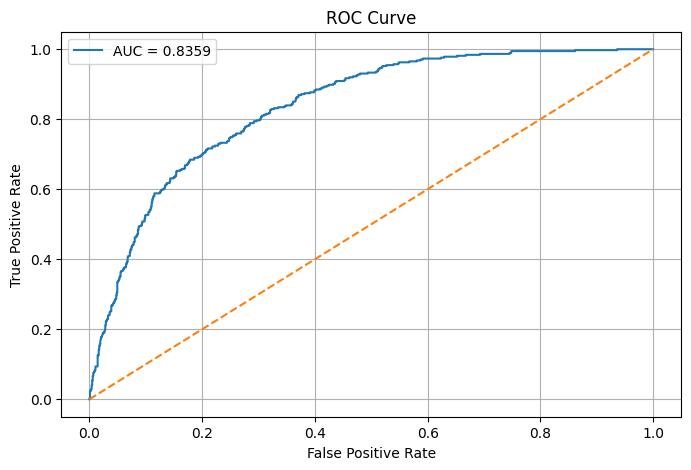


ROC AUC Score: 
0.8359


In [30]:
# =====================================================
# 13. ROC Curve
# =====================================================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(
    fpr, tpr, label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

print("\nROC AUC Score: ")
print(round(auc_score, 4))

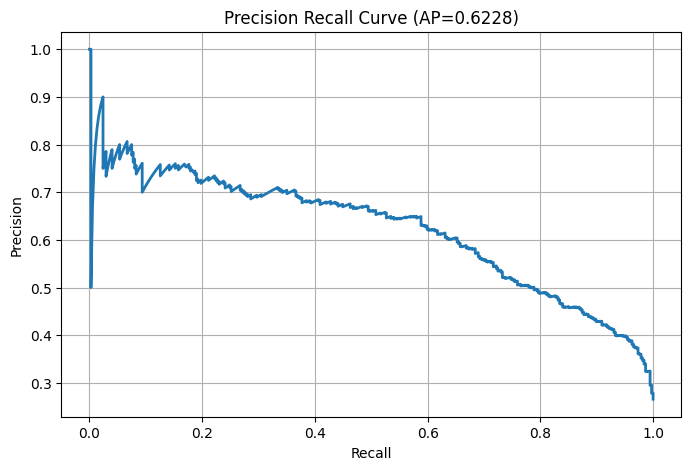


Average Precision Score: 
0.6228


In [31]:
# =====================================================
# 14. Precision Recall Curve
# =====================================================

precision, recall, thresholds = precision_recall_curve(
    y_test, y_prob
)

ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(
    recall, precision, linewidth= 2
)
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(f"Precision Recall Curve (AP={ap_score:.4f})")
plt.grid()
plt.show()

print("\nAverage Precision Score: ")
print(round(ap_score, 4))

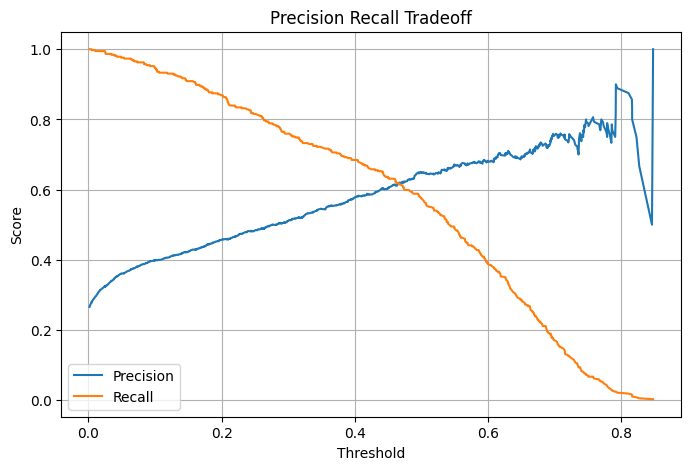

In [33]:
# =====================================================
# 15. Precision Recall Tradeoff
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds, precision[:-1], label="Precision"
)

plt.plot(
    thresholds, recall[:-1], label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("Precision Recall Tradeoff")

plt.legend()
plt.grid()
plt.show()

In [34]:
# =====================================================
# 16. RandomizedSearchCV
# =====================================================

param_distributions = {
    "model__C": np.logspace(-4, 4, 50),
    # C = 1 / λ
    # Generates 50 values between: 10^-4 and 10^4
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

random_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv = 5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters: ")
print(random_search.best_params_)

print("\nBest CV Score: ")
print(round(random_search.best_score_, 4))


Best Parameters: 
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(0.02811768697974228)}

Best CV Score: 
0.8052


In [36]:
# =====================================================
# 18. Evaluate Tuned Model
# =====================================================

best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("\nBaseline Accuracy: ")
print(round(baseline_accuracy, 4))

print("\nTuned Accuracy: ")
print(round(tuned_accuracy, 4))


Baseline Accuracy: 
0.8038

Tuned Accuracy: 
0.7989


In [37]:
# =====================================================
# 19. Accuracy Comparison
# =====================================================

comparison = pd.DataFrame({
    "Model" : [
        "Baseline Logistic Regression",
        "RandomizedSearchCV Logistic Regression"
    ],
    "Accuracy" : [
        baseline_accuracy,
        tuned_accuracy
    ]
})

print("\nModel Comparison\n")
print(comparison)


Model Comparison

                                    Model  Accuracy
0            Baseline Logistic Regression  0.803838
1  RandomizedSearchCV Logistic Regression  0.798863


In [38]:
# =====================================================
# 20. Threshold Tuning Example
# =====================================================

custom_threshold = 0.5

custom_predictions = (
    y_prob >= custom_threshold
).astype(int)

custom_accuracy = accuracy_score(
    y_test, custom_predictions
)

print("\nAccuracy at Threshold 0.30: ")
print(round(custom_accuracy, 4))

print("\nConfusion Matrix at Threshold 0.30")
print(
    confusion_matrix(
        y_test,
        custom_predictions
    )
)


Accuracy at Threshold 0.30: 
0.8038

Confusion Matrix at Threshold 0.30
[[917 116]
 [160 214]]
